# 02 — Choose Bandpass
# Giai đoạn 1 — Mục 1.2/1.3 — Chọn dải bandpass cho envelope
**Đầu ra**: `outputs/tables/bandpass_config.json`

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import io_utils, dsp, config as cfg

from common.pipeline import pick_file
from common.io_utils import load_de_signal
from common.dsp import compute_fft
from common.fast_kurtogram import fast_kurtogram

In [2]:
OUTPUT_DIR = Path("./outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(TABLES_DIR / "manifest_filtered.csv")

# Vẽ FFT để xác định vùng cộng hưởng

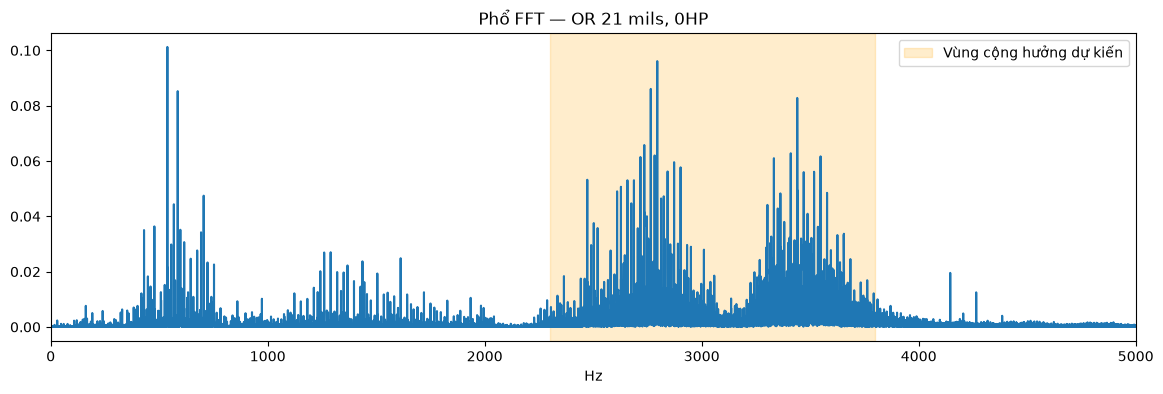

In [5]:
file_path = pick_file(manifest, label="OR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 5000)
plt.title("Phổ FFT — OR 21 mils, 0HP")

plt.axvspan(2300, 3800, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

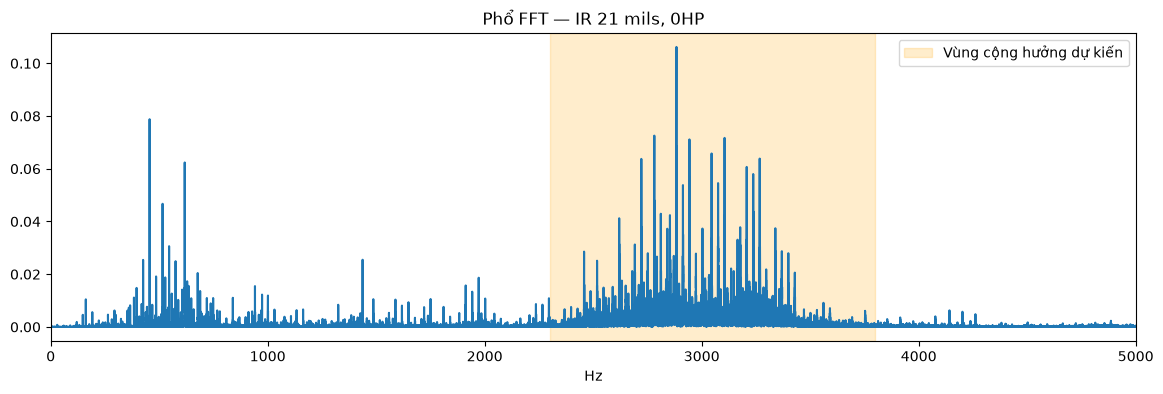

In [6]:
# Chọn 1 file IR lỗi rõ (diam 21 mils, tải 0HP) để quan sát
file_path = pick_file(manifest, label="IR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 5000)
plt.title("Phổ FFT — IR 21 mils, 0HP")

plt.axvspan(2300, 3800, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

- Chốt bandpass

In [7]:
# Chốt giá trị cuối cùng (đã điều chỉnh sau khi quan sát FFT ở các cell trên)
BAND_HZ = (2300, 3800)
LP_CUTOFF_HZ = 500

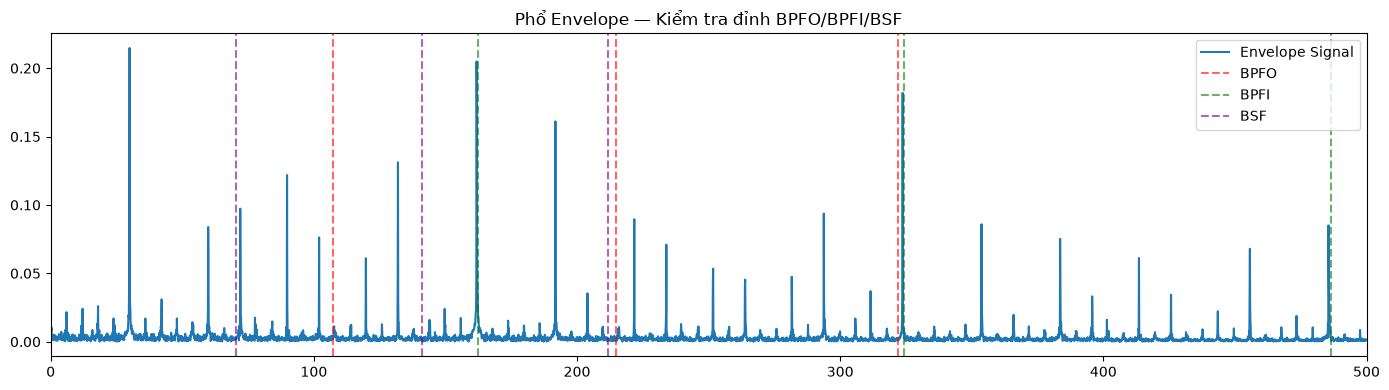

In [8]:
from common.dsp import square_law_envelope
from common.config import bearing_fault_frequencies, NOMINAL_RPM_BY_LOAD
import matplotlib.pyplot as plt

rpm = NOMINAL_RPM_BY_LOAD[0]
fault_freqs = bearing_fault_frequencies(rpm)

env = square_law_envelope(x, fs, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs_env, mag_env = compute_fft(env - env.mean(), fs)

# 1. Định nghĩa màu sắc riêng cho từng loại lỗi
color_map = {
    "BPFO": "red",    # Lỗi vòng ngoài - Đỏ
    "BPFI": "green",  # Lỗi vòng trong - Xanh lá
    "BSF": "purple"   # Lỗi con lăn - Tím
}

plt.figure(figsize=(14, 4))
plt.plot(freqs_env, mag_env, label="Envelope Signal", color='#1f77b4') # Màu xanh dương chuẩn

# 2. Vẽ các vạch tần số với màu tương ứng
for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        # Thủ thuật: Chỉ gán nhãn (label) ở sóng hài bậc 1 để Legend không bị in lặp 3 lần
        label_name = name if h == 1 else None
        
        plt.axvline(fault_freqs[name] * h, 
                    color=color_map[name], 
                    alpha=0.6, 
                    linestyle='--', 
                    label=label_name)

plt.xlim(0, 500)
plt.title("Phổ Envelope — Kiểm tra đỉnh BPFO/BPFI/BSF")

# 3. Kích hoạt hiển thị bảng chú thích
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Đang phân tích file: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\132@6_2.mat
RPM Tải 2: 1750 -> BPFO lý thuyết: 104.56 Hz


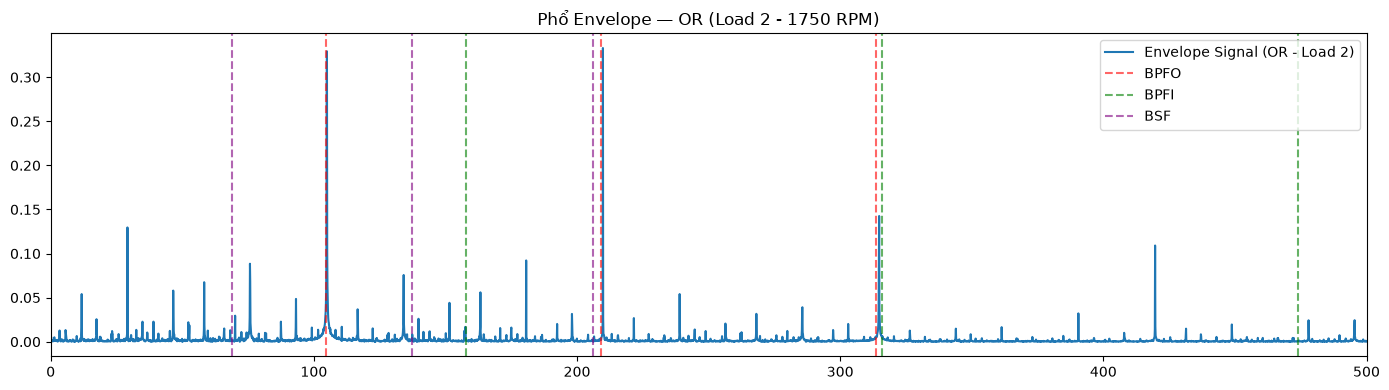

In [9]:
# 1. Lọc tìm file Lỗi vòng ngoài (OR) ở Tải 2 (2 HP)
# Đảm bảo bạn đang dùng đúng tên cột label trong dataframe của bạn (VD: 'OR', 'Outer Race'...)
or_load2_files = manifest[(manifest['label'] == 'OR') & (manifest['load_hp'] == 2)]

# Lấy file đầu tiên thỏa mãn điều kiện
selected_row = or_load2_files.iloc[0]
file_path = selected_row['file_path']
print(f"Đang phân tích file: {file_path}")

# 2. Load tín hiệu từ file mới
x = io_utils.load_de_signal(Path(file_path))
fs = 12000 # Hoặc fs = selected_row['fs']

# 3. Cập nhật RPM chuẩn của Tải 2 để tính tần số lỗi
rpm = NOMINAL_RPM_BY_LOAD[2]  # Tải 2 tương ứng 1750 RPM
fault_freqs = bearing_fault_frequencies(rpm)
print(f"RPM Tải 2: {rpm} -> BPFO lý thuyết: {fault_freqs['BPFO']:.2f} Hz")

# 4. Trích xuất đặc trưng Square-Law
env = square_law_envelope(x, fs, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs_env, mag_env = compute_fft(env - env.mean(), fs)

# 5. Vẽ đồ thị phân màu
color_map = {"BPFO": "red", "BPFI": "green", "BSF": "purple"}

plt.figure(figsize=(14, 4))
plt.plot(freqs_env, mag_env, label="Envelope Signal (OR - Load 2)", color='#1f77b4')

for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        label_name = name if h == 1 else None
        plt.axvline(fault_freqs[name] * h, 
                    color=color_map[name], 
                    alpha=0.6, 
                    linestyle='--', 
                    label=label_name)

plt.xlim(0, 500)
plt.title(f"Phổ Envelope — OR (Load 2 - {rpm} RPM)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

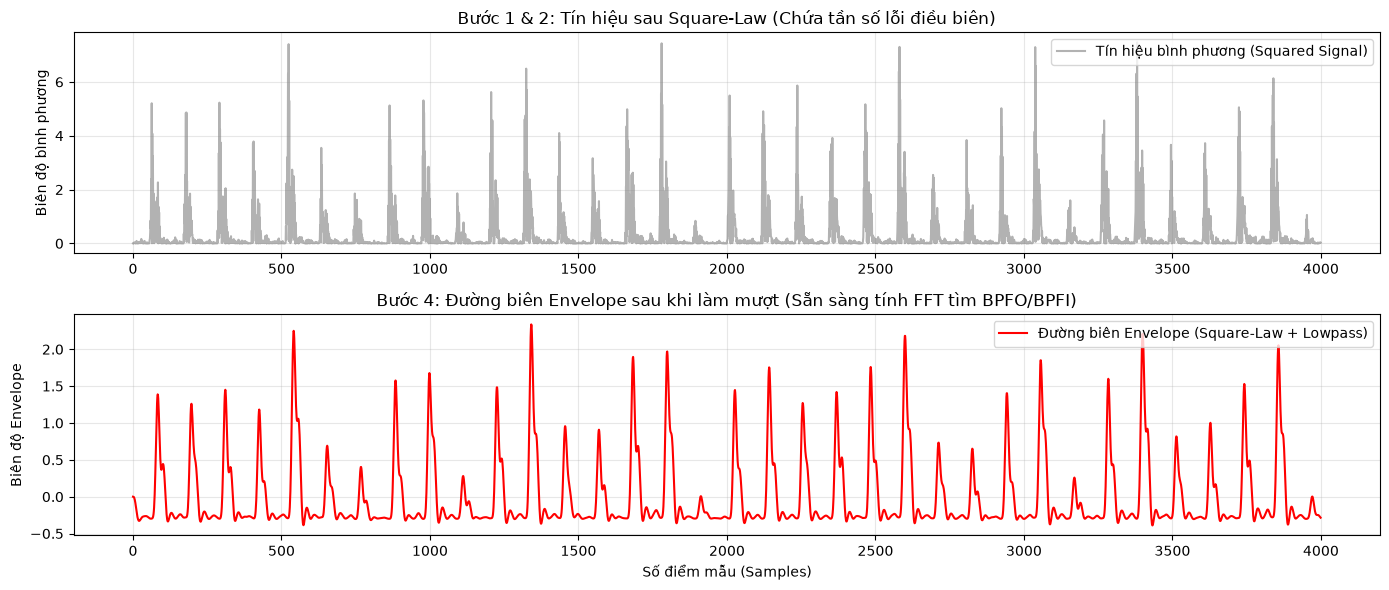

In [10]:
# Giả lập hoặc import hàm load dữ liệu và config của bạn ở đây
# from common import io_utils
# from common.config import SCOPE

# 1. Lấy một đoạn tín hiệu thô (Ví dụ: 4000 mẫu đầu tiên để thấy rõ các gai xung va đập)
# x_raw = io_utils.load_de_signal(Path("đường_dẫn_file_lỗi.mat"))
x_sample = x[:4000] 
fs = 12000 # Tần số lấy mẫu chuẩn
band_cfg = (2300, 3800) # Dải bandpass đã chọn ở Giai đoạn 0
lp_cutoff_hz = 500

# 2. Trích xuất đường biên bằng Square-Law tối ưu
env_signal = square_law_envelope(x_sample, fs, band=band_cfg, lp_cutoff=lp_cutoff_hz)

# 3. Vẽ đồ thị so sánh
plt.figure(figsize=(14, 6))

# Biểu đồ trên: Tín hiệu sau khi lọc Bandpass và bình phương (Square-Law)
plt.subplot(2, 1, 1)
plt.plot(x_sample ** 2, color='gray', alpha=0.6, label='Tín hiệu bình phương (Squared Signal)')
plt.title("Bước 1 & 2: Tín hiệu sau Square-Law (Chứa tần số lỗi điều biên)")
plt.ylabel("Biên độ bình phương")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# Biểu đồ dưới: Đường biên Envelope hoàn chỉnh sau khi qua bộ lọc Lowpass
plt.subplot(2, 1, 2)
plt.plot(env_signal, color='red', linewidth=1.5, label='Đường biên Envelope (Square-Law + Lowpass)')
plt.title("Bước 4: Đường biên Envelope sau khi làm mượt (Sẵn sàng tính FFT tìm BPFO/BPFI)")
plt.xlabel("Số điểm mẫu (Samples)")
plt.ylabel("Biên độ Envelope")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

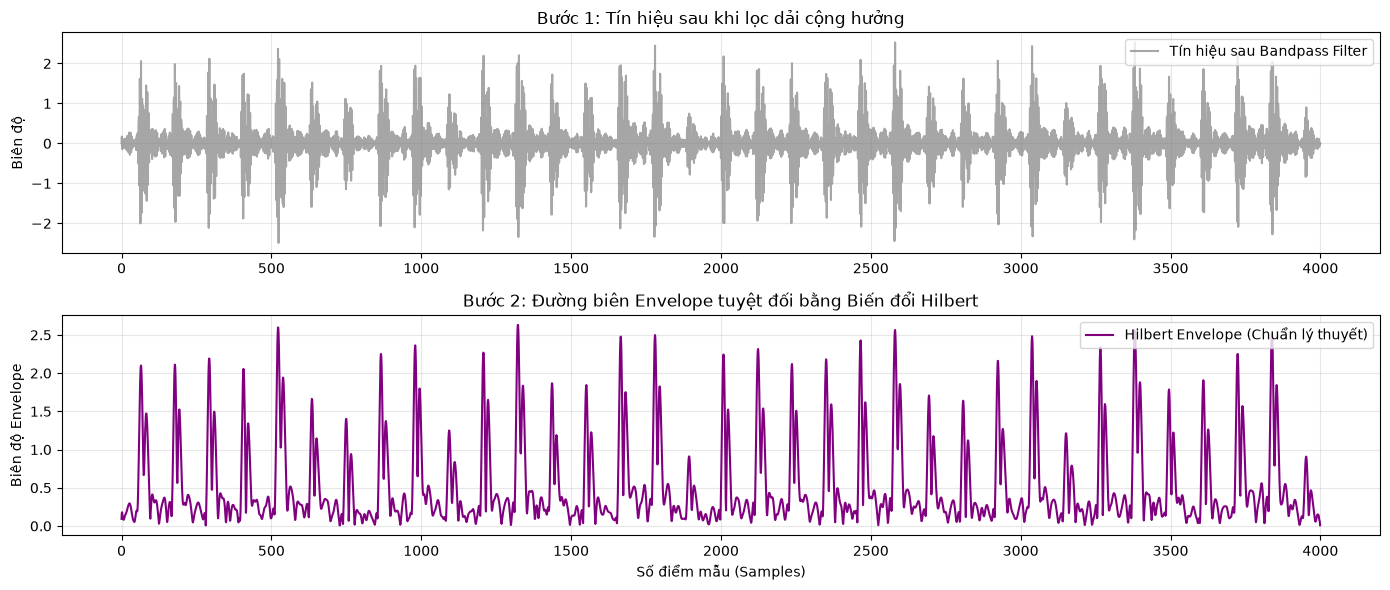

In [11]:
from scipy.signal import hilbert
from common.dsp import bandpass_filter

# 1. Lấy một đoạn tín hiệu thô (Ví dụ: 4000 mẫu đầu tiên)
x_sample = x[:4000] 
fs = 12000 
band_cfg = (2300, 3800) # Dải bandpass chuẩn

# 2. Bước 1: Lọc dải (Bandpass Filter)
filtered_signal = bandpass_filter(x_sample, fs, band_cfg[0], band_cfg[1])

# 3. Bước 2: Trích xuất đường biên bằng Biến đổi Hilbert
# analytic_signal chứa cả phần thực và phần ảo (số phức complex128)
analytic_signal = hilbert(filtered_signal)
hilbert_env = np.abs(analytic_signal) # Lấy biên độ tuyệt đối để làm đường bao

# 4. Vẽ đồ thị so sánh
plt.figure(figsize=(14, 6))

# Biểu đồ trên: Tín hiệu sau khi lọc Bandpass
plt.subplot(2, 1, 1)
plt.plot(filtered_signal, color='gray', alpha=0.7, label='Tín hiệu sau Bandpass Filter')
plt.title("Bước 1: Tín hiệu sau khi lọc dải cộng hưởng")
plt.ylabel("Biên độ")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# Biểu đồ dưới: Đường biên Envelope bằng Hilbert
plt.subplot(2, 1, 2)
plt.plot(hilbert_env, color='purple', linewidth=1.5, label='Hilbert Envelope (Chuẩn lý thuyết)')
plt.title("Bước 2: Đường biên Envelope tuyệt đối bằng Biến đổi Hilbert")
plt.xlabel("Số điểm mẫu (Samples)")
plt.ylabel("Biên độ Envelope")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- LƯU CẤU HÌNH

In [12]:
config = {"band_hz": list(BAND_HZ), "lp_cutoff_hz": LP_CUTOFF_HZ}
with open(TABLES_DIR / "bandpass_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Đã lưu cấu hình bandpass: {config}")


Đã lưu cấu hình bandpass: {'band_hz': [2300, 3800], 'lp_cutoff_hz': 500}
